# 직장/상주인구 × 추정매출 분석 → 소비패턴 연결
- 목적: 직장인구/상주인구 규모가 매출에 어떤 영향을 주는지 확인
- 데이터: 나경(직장/상주인구) × 지우(추정매출)
- 분석 기간: 2020~2024년 (매출 데이터가 2020년부터 시작)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

## Step 1. 데이터 로드

In [2]:
# 직장인구 데이터
df_직장 = pd.read_csv(
    '../data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv',
    encoding='cp949'
)

# 상주인구 데이터
df_상주 = pd.read_csv(
    '../data/07_상주인구/서울시 상권분석서비스(상주인구-상권).csv',
    encoding='cp949'
)

# 추정매출 데이터 (2020~2024년 파일 한번에 합치기)
매출_파일들 = sorted(glob.glob('../data/03_추정매출/*추정매출*.csv'))

print(f'매출 파일 수: {len(매출_파일들)}개')
for f in 매출_파일들:
    print(f'  {f}')

매출 파일 수: 6개
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2020년.csv
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2021년.csv
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2022년.csv
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2023년.csv
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2024년.csv
  ../data/03_추정매출\서울시_상권분석서비스(추정매출-상권)_2025년.csv


In [4]:
# 매출 파일 합치기 (2025년 제외)
매출_리스트 = []
for 파일 in 매출_파일들:
    if '2025' in 파일:  # 2025년 파일 제외
        continue
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    매출_리스트.append(df)

df_매출 = pd.concat(매출_리스트, ignore_index=True)

# 분석 기간 필터링
df_직장 = df_직장[df_직장['기준_년분기_코드'] < 20250]
df_상주 = df_상주[df_상주['기준_년분기_코드'] < 20250]

print(f'직장인구: {df_직장.shape}')
print(f'상주인구: {df_상주.shape}')
print(f'추정매출: {df_매출.shape}')

직장인구: (39276, 26)
상주인구: (34280, 29)
추정매출: (434199, 55)


## Step 2. 데이터 확인

In [5]:
# 매출 데이터 주요 컬럼 확인
print('매출 기간:', sorted(df_매출['기준_년분기_코드'].unique()))
print()
print('상권 구분:', df_매출['상권_구분_코드_명'].unique())
print()
print('매출 주요 컬럼:')
print([c for c in df_매출.columns if '매출' in c])

매출 기간: [np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]

상권 구분: <StringArray>
['골목상권', '발달상권', '전통시장', '관광특구']
Length: 4, dtype: str

매출 주요 컬럼:
['당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액', '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액', '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수', '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수', '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수', '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건

## Step 3. 데이터 전처리
- 직장/상주인구: 연도 + 상권 기준으로 집계
- 매출: 업종별로 쪼개져 있어서 → 연도 + 상권 기준으로 합산

In [6]:
# 연도 컬럼 추가
df_직장['연도'] = df_직장['기준_년분기_코드'].astype(str).str[:4].astype(int)
df_상주['연도'] = df_상주['기준_년분기_코드'].astype(str).str[:4].astype(int)
df_매출['연도'] = df_매출['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 직장인구: 연도 + 상권 기준 평균
df_직장_집계 = df_직장.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    총_직장인구=('총_직장_인구_수', 'mean')
).reset_index()

# 상주인구: 연도 + 상권 기준 평균
df_상주_집계 = df_상주.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    총_상주인구=('총_상주인구_수', 'mean')
).reset_index()

# 매출: 연도 + 상권 기준 합산 (업종별 → 상권별)
df_매출_집계 = df_매출.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    당월_매출=('당월_매출_금액', 'sum'),
    주중_매출=('주중_매출_금액', 'sum'),
    주말_매출=('주말_매출_금액', 'sum'),
    점심_매출=('시간대_11~14_매출_금액', 'sum'),
    저녁_매출=('시간대_17~21_매출_금액', 'sum')
).reset_index()

print(f'직장인구 집계: {df_직장_집계.shape}')
print(f'상주인구 집계: {df_상주_집계.shape}')
print(f'매출 집계: {df_매출_집계.shape}')

직장인구 집계: (9827, 4)
상주인구 집계: (9809, 4)
매출 집계: (7887, 8)


## Step 4. 데이터 합치기 (JOIN)
- 직장인구 + 상주인구 + 매출 세 개 합치기
- 기준: 연도 + 상권_코드
- 매출이 2020년부터라 2020~2024년 데이터만 남음

In [7]:
# 직장인구 + 상주인구 먼저 합치기
df_인구 = pd.merge(
    df_직장_집계,
    df_상주_집계[['연도', '상권_코드', '총_상주인구']],
    on=['연도', '상권_코드'],
    how='inner'
)

# 인구 + 매출 합치기
df_합 = pd.merge(
    df_인구,
    df_매출_집계,
    on=['연도', '상권_코드'],
    how='inner'
)

print(f'합친 데이터: {df_합.shape}')
print(f'기간: {sorted(df_합["연도"].unique())}')
df_합.head()

합친 데이터: (7786, 11)
기간: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,연도,상권_코드,상권_구분_코드_명_x,총_직장인구,총_상주인구,상권_구분_코드_명_y,당월_매출,주중_매출,주말_매출,점심_매출,저녁_매출
0,2020,3001491,관광특구,35438.25,5074.00,관광특구,267046350630,165608683334,101437667296,49113866539,87394778249
1,2020,3001492,관광특구,200886.25,1100.25,관광특구,1041812480128,842803732607,199008747521,328122412099,269891733722
2,2020,3001493,관광특구,35062.75,2479.25,관광특구,348499217126,266152536807,82346680319,86147421724,88502995871
3,2020,3001494,관광특구,62087.00,1762.75,관광특구,823128489194,683475697741,139652791453,245531621340,150117290785
4,2020,3001495,관광특구,96010.50,8748.25,관광특구,762236202129,481422839957,280813362172,148474883929,282754904954


In [8]:
# 상권_구분_코드_명 중복 제거 (_x만 남기고 이름 변경)
df_합 = df_합.drop(columns=['상권_구분_코드_명_y'])
df_합 = df_합.rename(columns={'상권_구분_코드_명_x': '상권_구분_코드_명'})

print(f'컬럼: {df_합.columns.tolist()}')

컬럼: ['연도', '상권_코드', '상권_구분_코드_명', '총_직장인구', '총_상주인구', '당월_매출', '주중_매출', '주말_매출', '점심_매출', '저녁_매출']


## Step 5. 직장인구 × 매출 분석
- 직장인구가 많은 상권일수록 주중/점심/저녁 매출이 높은지 확인

In [9]:
# 상권 유형별 직장인구 평균 vs 주중 매출 평균
유형별 = df_합.groupby('상권_구분_코드_명').agg(
    평균_직장인구=('총_직장인구', 'mean'),
    평균_주중매출=('주중_매출', 'mean'),
    평균_점심매출=('점심_매출', 'mean'),
    평균_저녁매출=('저녁_매출', 'mean'),
    평균_주말매출=('주말_매출', 'mean')
).reset_index()

print(유형별.round(0).to_string(index=False))

상권_구분_코드_명  평균_직장인구      평균_주중매출      평균_점심매출      평균_저녁매출      평균_주말매출
      골목상권    784.0 1.106559e+10 3.388657e+09 4.306867e+09 3.366501e+09
      관광특구  86887.0 5.837023e+11 2.144915e+11 2.163511e+11 2.098253e+11
      발달상권  11384.0 1.611836e+11 5.629673e+10 5.947652e+10 5.192247e+10
      전통시장    687.0 3.291789e+10 1.160908e+10 1.003359e+10 1.105231e+10


In [10]:
# 억 단위로 변환해서 보기 편하게
유형별_억 = 유형별.copy()
매출_컬럼 = ['평균_주중매출', '평균_점심매출', '평균_저녁매출', '평균_주말매출']
for col in 매출_컬럼:
    유형별_억[col] = (유형별_억[col] / 1e8).round(1)  # 억 단위

print(유형별_억.to_string(index=False))

상권_구분_코드_명      평균_직장인구  평균_주중매출  평균_점심매출  평균_저녁매출  평균_주말매출
      골목상권   783.612837    110.7     33.9     43.1     33.7
      관광특구 86886.541667   5837.0   2144.9   2163.5   2098.3
      발달상권 11383.558511   1611.8    563.0    594.8    519.2
      전통시장   687.258058    329.2    116.1    100.3    110.5


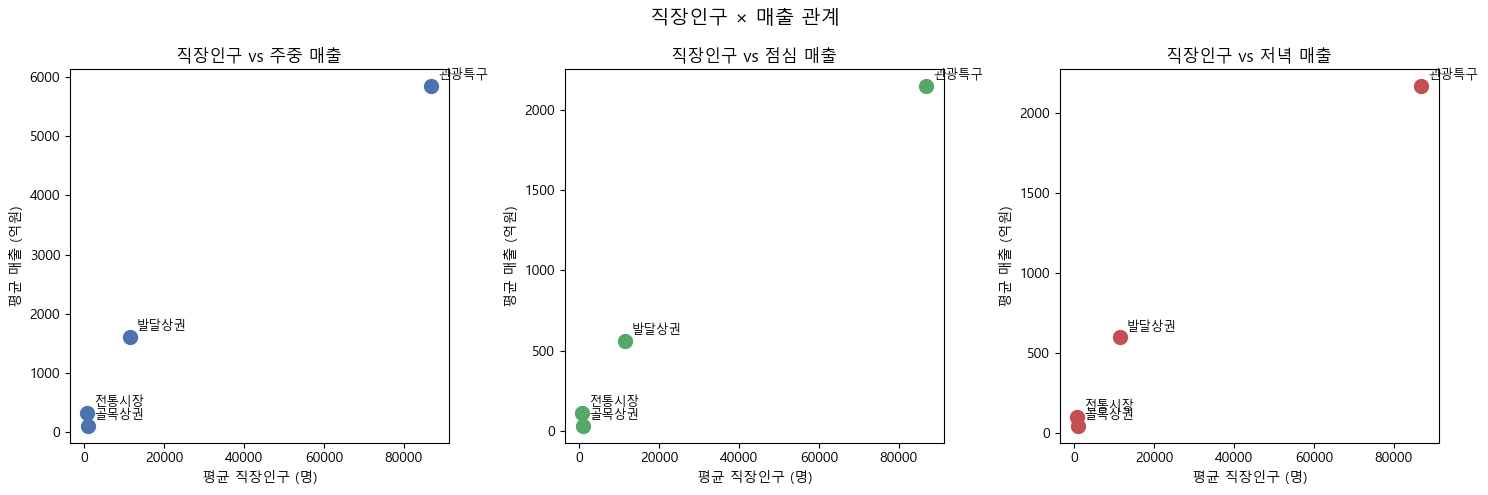

In [11]:
# 직장인구 vs 주중/점심/저녁 매출 비교 (상권 유형별)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

매출_항목 = ['평균_주중매출', '평균_점심매출', '평균_저녁매출']
제목 = ['직장인구 vs 주중 매출', '직장인구 vs 점심 매출', '직장인구 vs 저녁 매출']
색상 = ['#4C72B0', '#55A868', '#C44E52']

for i, (컬럼, 제목명, 색) in enumerate(zip(매출_항목, 제목, 색상)):
    axes[i].scatter(
        유형별_억['평균_직장인구'],
        유형별_억[컬럼],
        c=색, s=100
    )
    # 상권 유형 이름 표시
    for _, row in 유형별_억.iterrows():
        axes[i].annotate(
            row['상권_구분_코드_명'],
            (row['평균_직장인구'], row[컬럼]),
            textcoords='offset points', xytext=(5, 5), fontsize=9
        )
    axes[i].set_title(제목명, fontsize=12)
    axes[i].set_xlabel('평균 직장인구 (명)')
    axes[i].set_ylabel('평균 매출 (억원)')

plt.suptitle('직장인구 × 매출 관계', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# 시간대별 매출 비중 계산 (절대값 말고 비율로 보기)
유형별_억['점심_비중'] = (유형별_억['평균_점심매출'] / 유형별_억['평균_주중매출'] * 100).round(1)
유형별_억['저녁_비중'] = (유형별_억['평균_저녁매출'] / 유형별_억['평균_주중매출'] * 100).round(1)
유형별_억['주말_비중'] = (유형별_억['평균_주말매출'] / 유형별_억['평균_당월매출'] * 100).round(1)

print(유형별_억[['상권_구분_코드_명', '점심_비중', '저녁_비중', '주말_비중']].to_string(index=False))

KeyError: '평균_당월매출'

In [13]:
print(유형별_억.columns.tolist())

['상권_구분_코드_명', '평균_직장인구', '평균_주중매출', '평균_점심매출', '평균_저녁매출', '평균_주말매출', '점심_비중', '저녁_비중']


In [14]:
# 상권 유형별 평균 계산 (당월_매출 추가)
유형별 = df_합.groupby('상권_구분_코드_명').agg(
    평균_직장인구=('총_직장인구', 'mean'),
    평균_당월매출=('당월_매출', 'mean'),  # 추가
    평균_주중매출=('주중_매출', 'mean'),
    평균_점심매출=('점심_매출', 'mean'),
    평균_저녁매출=('저녁_매출', 'mean'),
    평균_주말매출=('주말_매출', 'mean')
).reset_index()

# 억 단위 변환
유형별_억 = 유형별.copy()
매출_컬럼 = ['평균_당월매출', '평균_주중매출', '평균_점심매출', '평균_저녁매출', '평균_주말매출']
for col in 매출_컬럼:
    유형별_억[col] = (유형별_억[col] / 1e8).round(1)

print(유형별_억.to_string(index=False))

상권_구분_코드_명      평균_직장인구  평균_당월매출  평균_주중매출  평균_점심매출  평균_저녁매출  평균_주말매출
      골목상권   783.612837    144.3    110.7     33.9     43.1     33.7
      관광특구 86886.541667   7935.3   5837.0   2144.9   2163.5   2098.3
      발달상권 11383.558511   2131.1   1611.8    563.0    594.8    519.2
      전통시장   687.258058    439.7    329.2    116.1    100.3    110.5


In [15]:
# 시간대별 매출 비중 계산
유형별_억['점심_비중'] = (유형별_억['평균_점심매출'] / 유형별_억['평균_주중매출'] * 100).round(1)
유형별_억['저녁_비중'] = (유형별_억['평균_저녁매출'] / 유형별_억['평균_주중매출'] * 100).round(1)
유형별_억['주말_비중'] = (유형별_억['평균_주말매출'] / 유형별_억['평균_당월매출'] * 100).round(1)

print(유형별_억[['상권_구분_코드_명', '점심_비중', '저녁_비중', '주말_비중']].to_string(index=False))

상권_구분_코드_명  점심_비중  저녁_비중  주말_비중
      골목상권   30.6   38.9   23.4
      관광특구   36.7   37.1   26.4
      발달상권   34.9   36.9   24.4
      전통시장   35.3   30.5   25.1


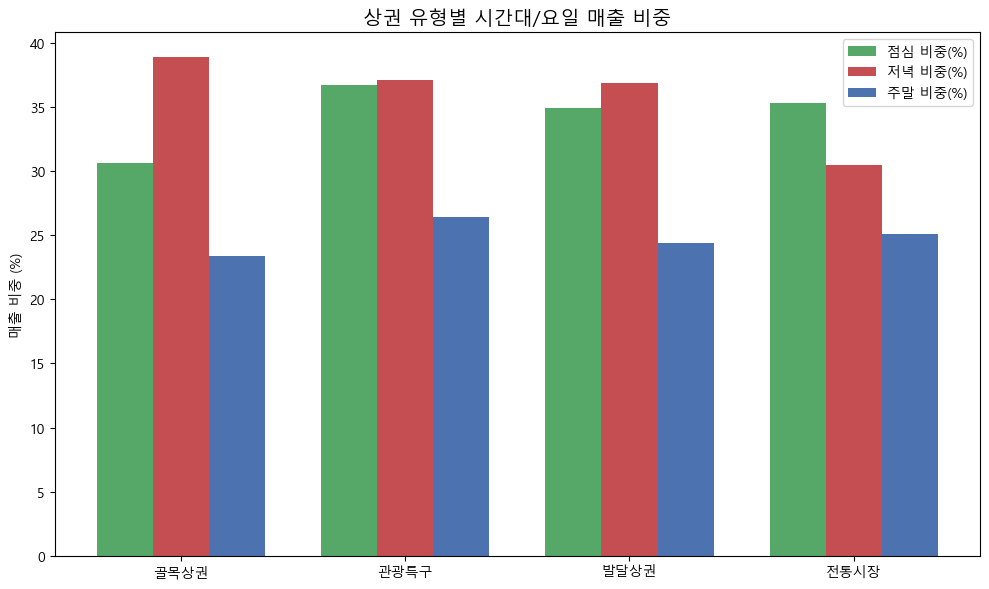

In [16]:
# 시간대별 매출 비중 비교 (상권 유형별)
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(유형별_억))
width = 0.25

# 점심/저녁/주말 비중 나란히 막대로
bars1 = ax.bar([i - width for i in x], 유형별_억['점심_비중'],
               width=width, label='점심 비중(%)', color='#55A868')
bars2 = ax.bar(x, 유형별_억['저녁_비중'],
               width=width, label='저녁 비중(%)', color='#C44E52')
bars3 = ax.bar([i + width for i in x], 유형별_억['주말_비중'],
               width=width, label='주말 비중(%)', color='#4C72B0')

ax.set_xticks(list(x))
ax.set_xticklabels(유형별_억['상권_구분_코드_명'])
ax.set_title('상권 유형별 시간대/요일 매출 비중', fontsize=14)
ax.set_ylabel('매출 비중 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5. 인사이트 - 직장인구 × 매출

### 핵심 발견
- 직장인구 많을수록 주중/점심/저녁 매출 모두 높음
  → 단, 절대값이 아닌 비중으로 봐야 소비패턴 차이가 보임

### 상권 유형별 소비패턴
- 골목상권: 저녁 비중 38.9% 1위 → 식당/술집 중심 저녁형 상권
- 관광특구: 점심/저녁 비중 비슷 → 직장인 + 관광객 소비 혼재
- 발달상권: 점심/저녁 균형 → 직장인 중심 상권
- 전통시장: 유일하게 점심 비중 > 저녁 비중 → 오전~점심형 장보기 상권

### 비즈니스 시사점
- 창업 업종 선택 시 상권 유형별 소비 시간대 고려 필수
- 골목상권 → 저녁 장사 업종 유리
- 전통시장 → 오전 장사 업종 유리

## Step 6. 상주인구 × 매출 분석
- 상주인구(거주자)가 많은 상권일수록 주말 매출이 높은지 확인

In [17]:
# 상권 유형별 상주인구 vs 주말 매출 비중
유형별_상주 = df_합.groupby('상권_구분_코드_명').agg(
    평균_상주인구=('총_상주인구', 'mean'),
    평균_당월매출=('당월_매출', 'mean'),
    평균_주말매출=('주말_매출', 'mean'),
    평균_주중매출=('주중_매출', 'mean')
).reset_index()

# 억 단위 변환
for col in ['평균_당월매출', '평균_주말매출', '평균_주중매출']:
    유형별_상주[col] = (유형별_상주[col] / 1e8).round(1)

# 주말 비중 계산
유형별_상주['주말_비중'] = (
    유형별_상주['평균_주말매출'] / 유형별_상주['평균_당월매출'] * 100
).round(1)

print(유형별_상주[['상권_구분_코드_명', '평균_상주인구', '평균_주말매출', '주말_비중']].to_string(index=False))

상권_구분_코드_명     평균_상주인구  평균_주말매출  주말_비중
      골목상권 2885.369375     33.7   23.4
      관광특구 3204.016667   2098.3   26.4
      발달상권 2349.675736    519.2   24.4
      전통시장  721.223951    110.5   25.1


## Step 6. 인사이트 - 상주인구 × 매출

### 핵심 발견
- 상주인구 많다고 주말 매출이 비례해서 높지 않음
  → 골목상권: 상주인구 2위지만 주말 비중 꼴찌
  → 거주자들이 주말에 다른 상권으로 나가서 소비하는 패턴

### 관광특구 예외
- 상주인구 1위 + 주말 비중 1위
- 단, 주말 매출을 견인하는 건 상주인구가 아니라 외부 관광객

### 비즈니스 시사점
- 상주인구 많은 상권 = 주말 매출 높다는 공식 성립 안 함
- 주말 매출을 높이려면 외부 유입 인구(관광객/유동인구) 확보가 핵심
- 골목상권 주말 매출 활성화 → 외부 방문객 유인 전략 필요

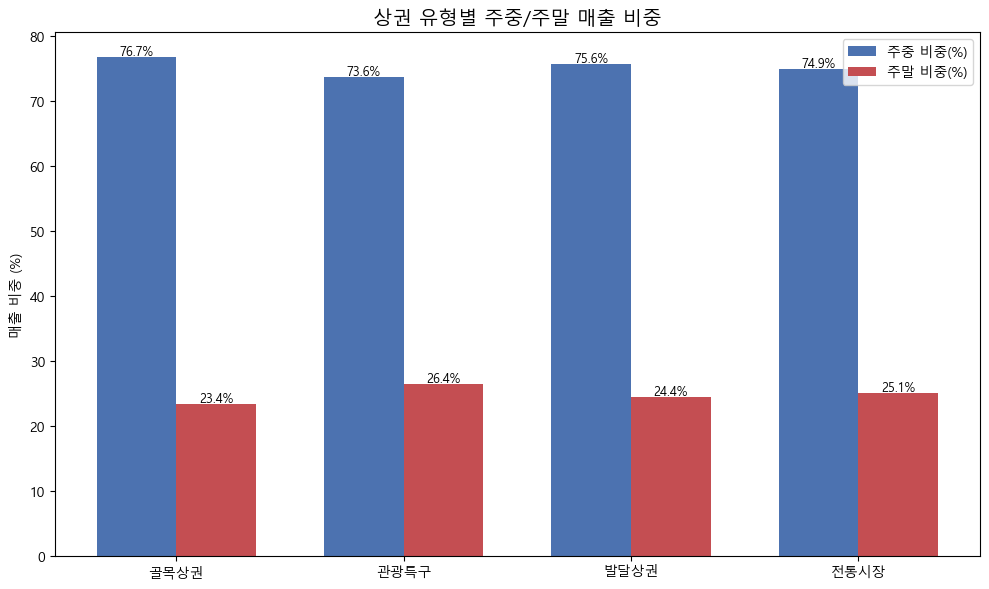

In [18]:
# 상권 유형별 주중/주말 매출 비중 비교
유형별_상주['주중_비중'] = (
    유형별_상주['평균_주중매출'] / 유형별_상주['평균_당월매출'] * 100
).round(1)

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(유형별_상주))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 유형별_상주['주중_비중'],
               width=width, label='주중 비중(%)', color='#4C72B0')
bars2 = ax.bar([i + width/2 for i in x], 유형별_상주['주말_비중'],
               width=width, label='주말 비중(%)', color='#C44E52')

# 막대 위에 수치 표시
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(유형별_상주['상권_구분_코드_명'])
ax.set_title('상권 유형별 주중/주말 매출 비중', fontsize=14)
ax.set_ylabel('매출 비중 (%)')
ax.legend()
plt.tight_layout()
plt.show()